In [1]:
# ============================================================
# Standard scientific libraries
# ============================================================

import numpy as np
import pandas as pd
import warnings

from scipy.integrate import cumulative_simpson
from scipy.interpolate import interp1d
from scipy.linalg import inv, cho_factor, cho_solve

import matplotlib as mpl
import matplotlib.pyplot as plt

# ============================================================
# Gaussian Process (GaPP package)
# ============================================================

from gapp import gp
from gapp import covariance

# ============================================================
# MCMC and posterior analysis
# ============================================================

import emcee
import multiprocessing as mp
from getdist import MCSamples, plots
from IPython.display import display, Math

# ============================================================
# Plot configuration
# ============================================================

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Nimbus Roman"]
})

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# ============================================================
# 1. Carregamento dos Dados Pantheon+SH0ES
# ============================================================

sne_dat_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES.dat"
sne_cov_path = "/home/brunowesley/projetos/MCMC-cosmo/Data/SNe/Pantheon+SH0ES_STAT+SYS.cov"

# Read data file
df = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")
df_sne = pd.read_csv(sne_dat_path, sep=r"\s+", comment="#", engine="python")

# Extract columns as numpy arrays
zCMB = df["zCMB"].values
mu   = df["MU_SH0ES"].values

# z_sne  = df_sne["zCMB"].values
# mu_obs = df_sne["MU_SH0ES"].values

N = len(mu)
# N = len(mu_obs)


# ============================================================
# Load covariance matrix
# ============================================================

# Pantheon+ cov file has first line = dimension
mcov = np.loadtxt(sne_cov_path)
# cov_sne = np.loadtxt(sne_cov_path)


# Sometimes first element is N (check this)
if mcov[0] == N:
# if cov_sne[0] == N:
    mcov = mcov[1:]
    #cov_sne = cov_sne[1:]

cov_mu = np.reshape(mcov, (N, N))
# cov_sne = np.reshape(cov_sne, (N, N))

# Inverse covariance (μ-space)
Icov_mu = np.linalg.inv(cov_mu)
# Icov_sne = np.linalg.inv(cov_sne)


print("Covariance matrix shape:", cov_mu.shape)
# print("Covariance matrix shape:", cov_sne.shape)

Covariance matrix shape: (1701, 1701)


In [3]:
# ============================================================
# Convert distance modulus -> luminosity distance
# ============================================================

# d_L in Mpc
dl = 10 ** ((mu / 5) - 5)

# ============================================================
# Propagate covariance
# ============================================================

# derivative ∂dL/∂μ = (ln10/5) dL
factor = (np.log(10) / 5) * dl

# Efficient propagation:
# C_dL = D C_mu D  ->  elementwise: C_ij = f_i f_j C_mu_ij
cov_dl = cov_mu * np.outer(factor, factor)

# Inverse covariance in dL space
Icov_dl = np.linalg.inv(cov_dl)

print("Propagated covariance shape:", cov_dl.shape)

# ============================================================
# Quick sanity check
# ============================================================

print("First 5 luminosity distances:")
print(dl[:5])

print("\nFirst diagonal elements of cov(dL):")
print(np.diag(cov_dl)[:5])

Propagated covariance shape: (1701, 1701)
First 5 luminosity distances:
[ 6.30579721  6.4741089  13.95275601 14.092239   14.29354654]

First diagonal elements of cov(dL):
[ 0.2679189   0.30726106  2.52912493  3.22105142 16.94278851]


In [ ]:
# ============================================================
# GP reconstruction
# ============================================================

# We reconstruct H(z) in the redshift interval covered by the data.
# The GP is trained by maximizing the marginal likelihood.

# Reconstruction range
zmin = 0.0
zmax = np.max(z_cc)

# Instantiate GP with SE kernel
# This kernel assumes smooth behavior of H(z)
# Reconstruction grid (200 points)
g1 = gp.GaussianProcess(
    z_cc,
    H_cc,
    H_err,
    covfunction=covariance.SquaredExponential,
    cXstar=(zmin, zmax, 200) 
)

# Train hyperparameters and compute posterior mean + variance
rec1, theta1 = g1.gp(thetatrain="True")

# Extract reconstructed quantities following GaPP convention:
# rec[:,0] = z
# rec[:,1] = mean
# rec[:,2] = standard deviation
zrec     = rec1[:, 0]  # z
hzrec    = rec1[:, 1]  # mean
sighzrec = rec1[:, 2]  # standard deviation

# Hubble constant estimate from z=0
H0    = hzrec[0]
sigH0 = sighzrec[0]

# Save reconstructed H(z)
# np.savetxt("Hz_CC_se_rec.dat", rec1)

# Print H0 and uncertanties
print(f"H0 = {H0:.3f} ± {sigH0:.3f} km/s/Mpc")

In [4]:
######## PROCESSO GAUSSIANO USANDO GAPP #################

# nomeando
x_gapp = zCMB
y_gapp = dl
e = cov_dl


# xmin, xmax and nstar are interpreted as two-dimensional vectors
xmin = 0.0
xmax = np.max(zCMB)
nstar = 200


# initial values of the hyperparameters of the squared-exponential covariance function
initheta = [2.0, 2.0]

# initialization of the Gaussian Process
g = gp.GaussianProcess(x_gapp, y_gapp, e, cXstar=(xmin, xmax, nstar))

# training of the hyperparameters and reconstruction of the function
(rec, theta) = g.gp(theta=initheta)

xi = rec[:, 0]

y_pred = rec[:, 1]
sigma  = rec[:, 2]

y_pred_95_less = y_pred - 1.96*sigma
y_pred_95_plus = y_pred + 1.96*sigma



# salvando os dados

N =  xi, y_pred, sigma

#np.savetxt('dlz_recon_covariance.csv', np.transpose(N), delimiter=', ')

  NIT   NF   F                       GTG
    0    1  1.231653780456082E+05   4.22706616E+06
tnc: fscale = 0.000162128
    1   12  4.676242236004161E+04   1.50184255E+08
    2   14  4.675015714934701E+04   2.72644364E+08
    3   17  1.713934007420424E+04   1.43305341E+08
tnc: stepmx = 1000
    4   20  1.153528697319303E+04   3.31191080E+06
    5   22  1.133084348210863E+04   4.16304492E+03
tnc: fscale = 0.00516622
    6   24  1.132919742355935E+04   2.85540591E+04
    7   27  9.115570701647801E+03   2.81894117E+03
    8   30  8.723948286723664E+03   6.01588569E+04
    9   34  8.646220181486107E+03   6.67479656E+02
   10   39  8.605273098180431E+03   9.95073799E+03
   11   43  8.553442600416285E+03   4.04677108E+02
   12   47  8.545695112258752E+03   3.28351850E+01
   13   52  8.529622010202376E+03   1.81677252E+02
   14   54  8.525721909235210E+03   5.85529052E+00
tnc: fscale = 0.137754
   15   56  8.525514291534859E+03   2.87620942E-01
   16   58  8.525495008825628E+03   1.43790795E-02


Optimized hyperparameters:
theta = [9.18007960e+03 2.36719984e+00]


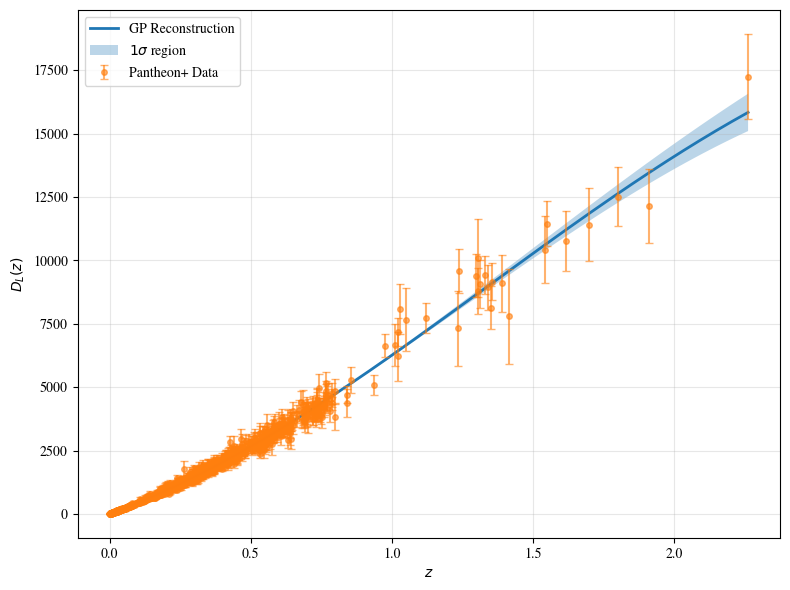

In [5]:
# ============================================================
# Plot: GP Reconstruction + Data (corrigido)
# ============================================================

# Garantir que NÃO estamos usando matriz completa no plot
e_plot = np.sqrt(np.diag(cov_dl))   # apenas desvio padrão

# Extrair reconstrução
x_rec = rec[:, 0]
y_rec = rec[:, 1]
y_err = rec[:, 2]

# Criar figura
plt.figure(figsize=(8,6))

# Reconstrução
plt.plot(x_rec, y_rec, lw=2, label='GP Reconstruction')

# Região 1σ
plt.fill_between(
    x_rec,
    y_rec - y_err,
    y_rec + y_err,
    alpha=0.3,
    label=r'$1\sigma$ region'
)

# Dados observacionais
plt.errorbar(
    x_gapp,
    y_gapp,
    yerr=e_plot,        # <-- AGORA CORRETO
    fmt='o',
    markersize=4,
    capsize=3,
    alpha=0.6,
    label='Pantheon+ Data'
)

plt.xlabel(r'$z$')
plt.ylabel(r'$D_L(z)$')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()